# Subject-identity leakage in affective EEG: a minimal, self-contained demo

**One model, one feature set, four evaluation protocols, two datasets. Only the data split changes.**

This notebook reproduces the empirical demonstration of the accompanying Perspective on **two datasets
recorded with different hardware**: DEAP (32-channel laboratory system) and DREAMER (14-channel consumer
Emotiv headset).

**The four protocols.** Consecutive protocols differ in exactly one respect, so the difference between
adjacent rows isolates one leakage channel:

| # | Protocol | Same trial across split? | Same participant? | Isolates |
|---|----------|--------------------------|-------------------|----------|
| 1 | Window-pooled *k*-fold | yes | yes | (fully leaky) |
| 2 | Trial-grouped, participant-pooled | **no** | yes | 1→2 = correlated windows |
| 3 | Subject-grouped windows | no | **no** | 2→3 = participant overlap |
| 4 | Leave-one-subject-out (trial-level) | no | no | 3→4 = evaluation unit |

**Two things this notebook is careful about.**

1. **Intervals resample subjects, not windows.** Resampling the tens of thousands of *correlated*
   windows treats them as independent observations and yields intervals several times too narrow. It can
   make a chance-level result look significantly different from chance. We resample participants.
2. **The label definition is stated, not assumed.** The primary labels use a single **global median**,
   which is the population-level target most of the literature adopts. It is *not* per-participant, and it
   leaves per-subject base rates badly skewed, so the participant label-prior channel is *active*. We
   therefore also repeat everything with a **per-subject median**, which flattens those base rates and
   removes the subject prior. (That second scheme needs the held-out participant's own ratings, so it is a
   diagnostic, not a deployable protocol.)

**Requirements:** `numpy scipy scikit-learn xgboost antropy pandas matplotlib` (CPU only).

**Data:** official DEAP preprocessed Python files `s01.dat...s32.dat`, and `DREAMER.mat`. Set the paths below.

**Runtime:** roughly 20-30 min total on a laptop CPU (feature extraction dominates).


In [1]:
import pickle, time, warnings
from pathlib import Path
import numpy as np, pandas as pd
import scipy.io as sio
from scipy.signal import welch
import antropy as ant
from sklearn.model_selection import StratifiedKFold, GroupKFold, LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# ---- config ----
DEAP_DIR    = Path("../../data/deap/data_preprocessed_python")  # <-- set to your DEAP folder
DREAMER_MAT = Path("../../DREAMER.mat")                          # <-- set to your DREAMER.mat
FS, BASELINE_S, WIN_S, STEP_S, DREAMER_LAST_S, SEED = 128, 3, 4, 2, 60, 17
# six frontal channels, shared by both montages, in a fixed order
CH = ["AF3", "F3", "F7", "AF4", "F4", "F8"]
DEAP_IDX = {"AF3":1, "F3":2, "F7":3, "AF4":17, "F4":19, "F8":20}     # DEAP Geneva order
DREAMER_ORDER = ['AF3','F7','F3','FC5','T7','P7','O1','O2','P8','T8','FC6','F4','F8','AF4']
BANDS = {"delta":(1,4),"theta":(4,8),"alpha":(8,13),"beta":(13,30),"gamma":(30,45)}
np.random.seed(SEED)

In [2]:
def window_features(seg):
    # Compact, fast qEEG features for one 6-channel window (rows in CH order).
    d = {}
    for ci, name in enumerate(CH):
        x = seg[ci]
        f, p = welch(x, FS, nperseg=min(len(x), FS*2)); tot = np.trapz(p, f) + 1e-12
        bp = {b: np.trapz(p[(f>=lo)&(f<hi)], f[(f>=lo)&(f<hi)])/tot for b,(lo,hi) in BANDS.items()}
        for b in BANDS: d[f"{name}_{b}_rel"] = bp[b]
        d[f"{name}_theta_alpha"] = bp["theta"]/(bp["alpha"]+1e-9)
        d[f"{name}_theta_beta"]  = bp["theta"]/(bp["beta"]+1e-9)
        dx, ddx = np.diff(x), np.diff(np.diff(x)); v = np.var(x)+1e-12
        mob = np.sqrt((np.var(dx)+1e-12)/v)
        d[f"{name}_hjorth_act"]  = v
        d[f"{name}_hjorth_mob"]  = mob
        d[f"{name}_hjorth_comp"] = np.sqrt((np.var(ddx)+1e-12)/(np.var(dx)+1e-12))/(mob+1e-12)
        d[f"{name}_perm_entropy"] = ant.perm_entropy(x, order=3, normalize=True)
    return d

def _windows(sig):  # sig: 6 x samples -> list of feature dicts
    n = sig.shape[1]
    return [window_features(sig[:, st:st+WIN_S*FS]) for st in range(0, n-WIN_S*FS+1, STEP_S*FS)]

def load_deap():
    idx = [DEAP_IDX[c] for c in CH]; rows, val, aro, subj, trial = [], [], [], [], []
    for sf in sorted(DEAP_DIR.glob("s*.dat")):
        s = int(sf.stem[1:]); dd = pickle.load(open(sf,"rb"), encoding="latin1")
        for t in range(dd["data"].shape[0]):
            sig = dd["data"][t, idx, BASELINE_S*FS:]
            w = _windows(sig); rows += w
            val += [dd["labels"][t,0]]*len(w); aro += [dd["labels"][t,1]]*len(w)
            subj += [s]*len(w); trial += [f"{s}_{t}"]*len(w)
    return pd.DataFrame(rows).values, np.array(val), np.array(aro), np.array(subj), np.array(trial)

def load_dreamer():
    idx = [DREAMER_ORDER.index(c) for c in CH]; rows, val, aro, subj, trial = [], [], [], [], []
    D = sio.loadmat(DREAMER_MAT, struct_as_record=False, squeeze_me=True)["DREAMER"]
    for si, s in enumerate(D.Data):
        sv, sa = np.array(s.ScoreValence), np.array(s.ScoreArousal)
        for t in range(len(s.EEG.stimuli)):
            sig = np.array(s.EEG.stimuli[t]).T[idx, -DREAMER_LAST_S*FS:]   # last 60 s, 6 frontal
            w = _windows(sig); rows += w
            val += [sv[t]]*len(w); aro += [sa[t]]*len(w)
            subj += [si]*len(w); trial += [f"{si}_{t}"]*len(w)
    return pd.DataFrame(rows).values, np.array(val), np.array(aro), np.array(subj), np.array(trial)

In [3]:
# ---------------- labels ----------------
# PRIMARY: one global median over the whole dataset. This is the population-level target most of
# the literature adopts. It is NOT per-participant, and it does NOT balance classes within a
# participant -- per-subject base rates stay skewed, so the label-prior channel is ACTIVE.
def labels_global_median(r, subj):
    return (r >= np.median(r)).astype(int)

# SENSITIVITY: each participant's own median. This flattens per-subject base rates to ~0.50 and so
# removes the subject label prior. NOTE it needs the held-out participant's own ratings, and it
# defines a WITHIN-PERSON RELATIVE-STATE target, not an absolute one. Diagnostic, not deployable.
def labels_subject_median(r, subj):
    y = np.zeros(len(r), int)
    for s in np.unique(subj):
        m = subj == s
        y[m] = (r[m] >= np.median(r[m])).astype(int)
    return y

def base_rates(y, subj):
    v = np.array([y[subj == s].mean() for s in np.unique(subj)])
    return v.mean(), v.std(), v.min(), v.max()

t0 = time.time(); DATA = {}
for name, loader in [("DEAP", load_deap), ("DREAMER", load_dreamer)]:
    X, val, aro, subj, trial = loader()
    DATA[name] = dict(X=X, val=val, aro=aro, subj=subj, trial=trial)
    print(f"{name}: {X.shape[0]} windows x {X.shape[1]} feats, {len(set(subj))} subjects  "
          f"[{time.time()-t0:.0f}s]")
    for sch, fn in [("global median", labels_global_median), ("per-subject median", labels_subject_median)]:
        for tgt, r in [("valence", val), ("arousal", aro)]:
            y = fn(r, subj); m, sd, lo, hi = base_rates(y, subj)
            print(f"   {sch:19s} {tgt:8s}: overall pos-rate {y.mean():.3f} | "
                  f"per-subject base rate {m:.2f} +/- {sd:.2f} (min {lo:.2f}, max {hi:.2f})")

DEAP: 37120 windows x 66 feats, 32 subjects  [191s]
   global median       valence : overall pos-rate 0.502 | per-subject base rate 0.50 +/- 0.17 (min 0.28, max 1.00)
   global median       arousal : overall pos-rate 0.500 | per-subject base rate 0.50 +/- 0.15 (min 0.15, max 0.72)
   per-subject median  valence : overall pos-rate 0.502 | per-subject base rate 0.50 +/- 0.01 (min 0.50, max 0.53)
   per-subject median  arousal : overall pos-rate 0.503 | per-subject base rate 0.50 +/- 0.01 (min 0.50, max 0.53)
DREAMER: 12006 windows x 66 feats, 23 subjects  [253s]
   global median       valence : overall pos-rate 0.611 | per-subject base rate 0.61 +/- 0.13 (min 0.39, max 0.78)
   global median       arousal : overall pos-rate 0.725 | per-subject base rate 0.72 +/- 0.14 (min 0.50, max 0.94)
   per-subject median  valence : overall pos-rate 0.645 | per-subject base rate 0.64 +/- 0.11 (min 0.50, max 0.78)
   per-subject median  arousal : overall pos-rate 0.652 | per-subject base rate 0.65 +/-

In [4]:
def model():
    return XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.1,
                         subsample=0.8, colsample_bytree=0.8, eval_metric="logloss",
                         random_state=SEED, n_jobs=4, verbosity=0)

# 95% CI resampling SUBJECTS, the unit of independence. Resampling rows (windows) instead treats
# correlated segments as independent and gives intervals several times too narrow -- enough to make
# a chance-level cell look significantly different from chance.
def boot_ci_subject(y, p, s, n=1000, seed=SEED):
    rng = np.random.default_rng(seed); subs = np.unique(s)
    by = {u: np.where(s == u)[0] for u in subs}; out = []
    for _ in range(n):
        idx = np.concatenate([by[u] for u in rng.choice(subs, len(subs), replace=True)])
        if len(np.unique(y[idx])) == 2: out.append(roc_auc_score(y[idx], p[idx]))
    return float(np.percentile(out, 2.5)), float(np.percentile(out, 97.5))

def _oof(X, y, splits, scale=False):
    oof = np.zeros(len(y))
    for tr, te in splits:
        if scale:
            sc = StandardScaler().fit(X[tr]); Xtr, Xte = sc.transform(X[tr]), sc.transform(X[te])
        else:
            Xtr, Xte = X[tr], X[te]
        m = model(); m.fit(Xtr, y[tr]); oof[te] = m.predict_proba(Xte)[:, 1]
    return oof

# --- P1: window-pooled k-fold. Same trial AND same participant bridge the split (fully leaky).
def p1_window_pooled(X, y, subj, trial):
    oof = _oof(X, y, StratifiedKFold(5, shuffle=True, random_state=SEED).split(X, y))
    return roc_auc_score(y, oof), boot_ci_subject(y, oof, subj)

# --- P2: trial-grouped but PARTICIPANT-POOLED. No trial bridges the split; participants still do.
#     P1 - P2 is the correlated-window effect. THIS IS THE CONTROL THE DECOMPOSITION NEEDS.
def p2_trial_grouped(X, y, subj, trial):
    oof = _oof(X, y, GroupKFold(5).split(X, y, groups=trial))
    return roc_auc_score(y, oof), boot_ci_subject(y, oof, subj)

# --- P3: subject-grouped windows. No participant bridges the split.
#     P2 - P3 is the participant-overlap (identity) effect.
def p3_subject_grouped(X, y, subj, trial):
    oof = _oof(X, y, GroupKFold(5).split(X, y, groups=subj))
    return roc_auc_score(y, oof), boot_ci_subject(y, oof, subj)

# --- P4: LOSO, trial-aggregated, train-only scaling. P3 - P4 is the evaluation-unit effect.
def p4_loso_trial(X, y, subj, trial):
    preds, trues, tsub = [], [], []
    for tr, te in LeaveOneGroupOut().split(X, y, groups=subj):
        sc = StandardScaler().fit(X[tr]); m = model(); m.fit(sc.transform(X[tr]), y[tr])
        p = m.predict_proba(sc.transform(X[te]))[:, 1]; tt = trial[te]
        for ut in np.unique(tt):
            preds.append(p[tt == ut].mean()); trues.append(y[te][tt == ut][0]); tsub.append(subj[te][0])
    preds, trues, tsub = np.array(preds), np.array(trues), np.array(tsub)
    return roc_auc_score(trues, preds), boot_ci_subject(trues, preds, tsub)

# --- identity probe. NOTE: it must be TRIAL-grouped, not subject-grouped: under LOSO the test
#     participants are absent from training, so closed-set identity decoding is undefined.
def subject_id_acc(X, subj, trial):
    s0 = subj - subj.min(); oof = np.zeros(len(s0), int)
    for tr, te in GroupKFold(5).split(X, s0, groups=trial):
        m = XGBClassifier(n_estimators=150, max_depth=4, learning_rate=0.2, n_jobs=4, verbosity=0)
        m.fit(X[tr], s0[tr]); oof[te] = m.predict(X[te])
    return accuracy_score(s0, oof), 1/len(set(s0))

In [5]:
PROTOCOLS = [("1. Window-pooled", p1_window_pooled),
             ("2. Trial-grouped,\nparticipant-pooled", p2_trial_grouped),
             ("3. Subject-grouped", p3_subject_grouped),
             ("4. Leave-one-\nsubject-out", p4_loso_trial)]
SCHEMES = [("global median", labels_global_median), ("per-subject median", labels_subject_median)]

results = {}
for ds, d in DATA.items():
    results[ds] = {"sid": subject_id_acc(d["X"], d["subj"], d["trial"])}
    for sch, fn in SCHEMES:
        results[ds][sch] = {}
        for tgt, r in [("valence", d["val"]), ("arousal", d["aro"])]:
            y = fn(r, d["subj"])
            results[ds][sch][tgt] = {p: f(d["X"], y, d["subj"], d["trial"]) for p, f in PROTOCOLS}

for ds in DATA:
    acc, ch = results[ds]["sid"]
    print(f"\n=== {ds} ===  subject-identity decoding: {acc:.3f} (chance {ch:.3f})")
    for sch, _ in SCHEMES:
        print(f"\n  [{sch} labels]")
        print(f"  {'protocol':<24}{'valence AUC [95% CI]':<30}{'arousal AUC [95% CI]'}")
        for p, _ in PROTOCOLS:
            av, (lv, hv) = results[ds][sch]["valence"][p]
            aa, (la, ha) = results[ds][sch]["arousal"][p]
            print(f"  {p.replace(chr(10),' '):<24}{av:.3f} [{lv:.3f}, {hv:.3f}]      "
                  f"{aa:.3f} [{la:.3f}, {ha:.3f}]")

# The decomposition the paper reports:
print("\n\n=== LEAKAGE DECOMPOSITION (global-median labels) ===")
for ds in DATA:
    for tgt in ("valence", "arousal"):
        R = results[ds]["global median"][tgt]
        a = [R[p][0] for p, _ in PROTOCOLS]
        print(f"{ds:8s} {tgt:8s}: correlated windows = {a[0]-a[1]:+.3f} | "
              f"participant overlap = {a[1]-a[2]:+.3f} | evaluation unit = {a[2]-a[3]:+.3f}")


=== DEAP ===  subject-identity decoding: 0.990 (chance 0.031)

  [global median labels]
  protocol                valence AUC [95% CI]          arousal AUC [95% CI]
  1. Window-pooled        0.711 [0.671, 0.753]      0.704 [0.674, 0.732]
  2. Trial-grouped, participant-pooled0.651 [0.602, 0.699]      0.636 [0.595, 0.673]
  3. Subject-grouped      0.515 [0.468, 0.559]      0.548 [0.508, 0.590]
  4. Leave-one- subject-out0.516 [0.457, 0.577]      0.549 [0.495, 0.609]

  [per-subject median labels]
  protocol                valence AUC [95% CI]          arousal AUC [95% CI]
  1. Window-pooled        0.616 [0.595, 0.634]      0.628 [0.609, 0.648]
  2. Trial-grouped, participant-pooled0.486 [0.463, 0.509]      0.519 [0.488, 0.546]
  3. Subject-grouped      0.509 [0.495, 0.523]      0.533 [0.518, 0.550]
  4. Leave-one- subject-out0.512 [0.492, 0.533]      0.547 [0.523, 0.572]

=== DREAMER ===  subject-identity decoding: 0.875 (chance 0.043)

  [global median labels]
  protocol              

saved ../figures/fig2_collapse.png / .pdf


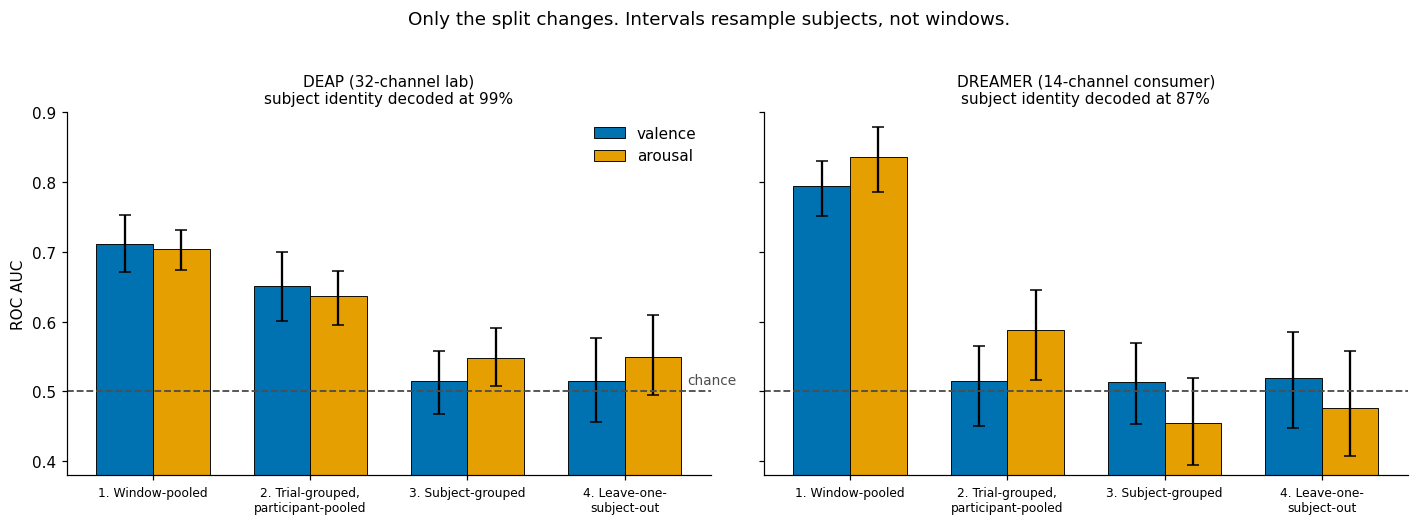

In [6]:
names = [p[0] for p in PROTOCOLS]; x = np.arange(len(names)); w = 0.36
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
titles = {"DEAP":"DEAP (32-channel lab)", "DREAMER":"DREAMER (14-channel consumer)"}
for ax, ds in zip(axes, DATA):
    for i,(tgt,color) in enumerate([("valence","#0072B2"),("arousal","#E69F00")]):
        R = results[ds]["global median"][tgt]
        vals = [R[n][0] for n in names]
        err  = [[R[n][0]-R[n][1][0] for n in names], [R[n][1][1]-R[n][0] for n in names]]
        ax.bar(x+(i-0.5)*w, vals, w, yerr=err, capsize=4, label=tgt, color=color,
               edgecolor="black", lw=0.6)
    ax.axhline(0.5, ls="--", color="0.3", lw=1.2)
    ax.set_xticks(x); ax.set_xticklabels(names, fontsize=8)
    ax.set_title(f"{titles[ds]}\nsubject identity decoded at {results[ds]['sid'][0]*100:.0f}%", fontsize=10)
    for sp in ("top","right"): ax.spines[sp].set_visible(False)
axes[0].set_ylim(0.38, 0.90); axes[0].set_ylabel("ROC AUC"); axes[0].legend(frameon=False)
axes[0].text(len(names)-0.6, 0.51, "chance", color="0.3", fontsize=9)
fig.suptitle("Only the split changes. Intervals resample subjects, not windows.", y=1.02)
fig.tight_layout()
fig.savefig("../figures/fig2_collapse.png", dpi=200, bbox_inches="tight")
fig.savefig("../figures/fig2_collapse.pdf", bbox_inches="tight")
plt.show(); print("saved ../figures/fig2_collapse.png / .pdf")

## What this shows

The classifier, the features and the labels are **identical** across the four bars in each panel. The only
thing that changes is **how the data is split**.

1. **Correlated windows leak.** Going from protocol 1 to protocol 2 changes nothing except that sibling
   windows of a trial can no longer straddle the split. On DREAMER this alone accounts for most of the
   apparent signal.
2. **Participant identity leaks.** Going from protocol 2 to protocol 3 changes nothing except that no
   participant appears on both sides. On DEAP this is the larger of the two channels. Which channel
   dominates is **dataset-dependent**, which is exactly why the intermediate control is necessary: a
   pooled-to-subject-grouped comparison removes both at once and cannot attribute the loss to either.
3. **The prior is the route.** Re-run with per-subject-median labels, which flatten each participant's base
   rate to ~0.50, and the advantage that participant overlap conferred largely disappears. Participant
   overlap pays chiefly by handing the model each participant's habitual **label prior**.
4. **Identity is available to be exploited.** The same features decode *which participant* produced a
   recording at ~99% (DEAP) and ~88% (DREAMER), against chance of 3% and 4%.

Because the two datasets use different headsets, the collapse cannot be a hardware artefact.

**The reproducible take-away:** a leak-free, subject-independent protocol is the only one whose number
speaks to population-level emotion decoding, and under it this pipeline does not beat chance. Note also
that the intervals here resample **subjects**; had we resampled windows, the DREAMER arousal cell would
have appeared *significantly below chance* purely as an artefact of treating correlated windows as
independent.